In [2]:
import os
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_portefeuille = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_portefeuille_2023_11.csv", sep=";")
df_consommations = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_consommations_2023_11.csv", sep=";")
df_reclamations = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_reclamations_2023_11.csv", sep=";")
df_interactions = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_interactions_2023_11.csv", sep=";")
df_impayes = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_impayes_2023_11.csv", sep=";")

/tmp/ipykernel_294511/1791649183.py:1: DtypeWarning: Columns (31,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df_portefeuille = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_portefeuille_2023_11.csv", sep=";")


In [4]:
import agregation
from agregation import * 

In [5]:
df1 = aggregate_consommations(df_consommations)
df2 = aggregate_reclamations(df_reclamations)
df3 = aggregate_interactions(df_interactions)
df4 = aggregate_impayes(df_impayes)

/home/onyxia/work/bdc-alptis-g2/agregation.py:253: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("client_code").apply(build_info_dict).reset_index(drop=True)
/home/onyxia/work/bdc-alptis-g2/agregation.py:378: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_interaction_historique_mail = df_mail.groupby("client_code").apply(


In [6]:
df_final = (
    df_portefeuille
    .set_index("client_code")
    .join(df1.set_index("client_code"), how="left")
    .join(df2.set_index("client_code"), how="left")
    .join(df3.set_index("client_code"), how="left")
    .join(df4.set_index("client_code"), how="left")
    .reset_index()
)


In [7]:
df_final.head()

,client_code,client_age_souscripteur,client_sexe_souscripteur,client_ro_souscripteur,client_code_postal,client_departement,client_departement_avant_changement_12_mois,client_a_conjoint,client_nb_enfants,client_structure_familiale,...,impaye_nb_actions,impaye_montant_total,nb_impaye_action_1er_impaye,nb_impaye_action_1ere_lettre_relance,nb_impaye_action_2eme_impaye,nb_impaye_action_annonce_contentieux,nb_impaye_action_en_recouvrement,nb_impaye_action_mise_en_demeure,nb_impaye_action_suspension_garanties,impaye_duree_max_action_jours
0,21736,97,F,SS,69100,69,NaN,0.0,0.0,femme ss enfant,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,22037,95,F,SS,26230,26,NaN,0.0,0.0,femme ss enfant,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,22331,88,M,TNS,69760,69,NaN,1.0,0.0,couple ss enfant,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,22604,95,F,TNS,69003,69,NaN,0.0,0.0,femme ss enfant,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,22702,90,M,TNS,69100,69,NaN,1.0,0.0,couple ss enfant,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
for col in df_final.columns:
    print(col)

client_code
client_age_souscripteur
client_sexe_souscripteur
client_ro_souscripteur
client_code_postal
client_departement
client_departement_avant_changement_12_mois
client_a_conjoint
client_nb_enfants
client_structure_familiale
client_nb_assures_contrat
client_a_garantie_prevoyance
client_produit
client_garantie_base
client_garantie_base_plus_options
client_millesime_tarifaire_produit
client_zone_tarifaire
client_type_zone_tarifaire
client_est_contrat_madelin
client_date_debut_effet_garantie
client_anciennete_contrat_annees
client_cotisations_annualisees_n_moins2
client_cotisations_annualisees_n_moins1
client_cotisations_annualisees_n
client_cotisations_annualisees_n_plus1
client_mode_paiement
client_frequence_paiement
client_nom_banque
client_nps_date_reponse_n
client_nps_note_reco_n
client_nps_verbatim_n
client_nps_date_reponse_n_moins1
client_nps_note_reco_n_moins1
client_nps_verbatim_n_moins1
courtier_code_partenaire
courtier_anciennete_annees
courtier_code_apporteur
courtier_code

target_resiliation_6mois recla_nombre impaye_nb_actions impaye_montant_total interaction_nb_total recla_sensible_resiliation

In [10]:
# Change NA by 0
vars_to_fill = [
    'recla_nombre',
    'impaye_nb_actions',
    'impaye_montant_total',
    'interaction_nb_total',
    'recla_sensible_resiliation'
]

df_final[vars_to_fill] = df_final[vars_to_fill].fillna(0)

In [24]:
taux_resiliation_recla_sensible_resiliation = df_final.groupby('recla_sensible_resiliation').agg(
    nb_clients = ('target_resiliation_6mois', 'count'),
    taux_resiliation = ('target_resiliation_6mois', 'mean')
)

taux_resiliation_recla_sensible_resiliation

,nb_clients,taux_resiliation
recla_sensible_resiliation,,
0.0,132536,0.108944
1.0,38,0.289474
2.0,2,0.000000


In [14]:
df_final.groupby('target_resiliation_6mois')[
    ['recla_nombre', 'impaye_nb_actions', 'impaye_montant_total', 'interaction_nb_total']
].mean()


,recla_nombre,impaye_nb_actions,impaye_montant_total,interaction_nb_total
target_resiliation_6mois,,,,
0,0.073913,0.119601,37.984172,1.742986
1,0.160138,0.100969,29.783719,3.176540


In [16]:
taux_resiliation_par_recla = df_final.groupby('recla_nombre').agg(
    nb_clients = ('target_resiliation_6mois', 'count'),
    taux_resiliation = ('target_resiliation_6mois', 'mean')
)

taux_resiliation_par_recla

,nb_clients,taux_resiliation
recla_nombre,,
0.0,125183,0.104120
1.0,5354,0.182294
2.0,1274,0.196232
3.0,405,0.229630
4.0,176,0.215909
5.0,85,0.305882
6.0,46,0.217391
7.0,18,0.333333
8.0,10,0.600000


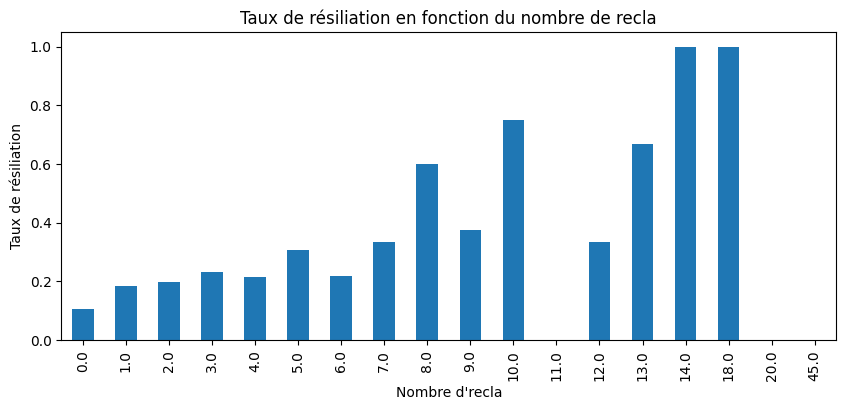

In [23]:
taux_resiliation_par_interaction = (
    df_final.groupby('recla_nombre')['target_resiliation_6mois']
    .mean()
)

taux_resiliation_par_interaction.plot(kind='bar', figsize=(10,4))

plt.ylabel("Taux de résiliation")
plt.xlabel("Nombre d'recla")
plt.title("Taux de résiliation en fonction du nombre de recla")
plt.show()


In [31]:
df_final['recla_nombre_bin'] = df_final['recla_nombre'].clip(upper=5)


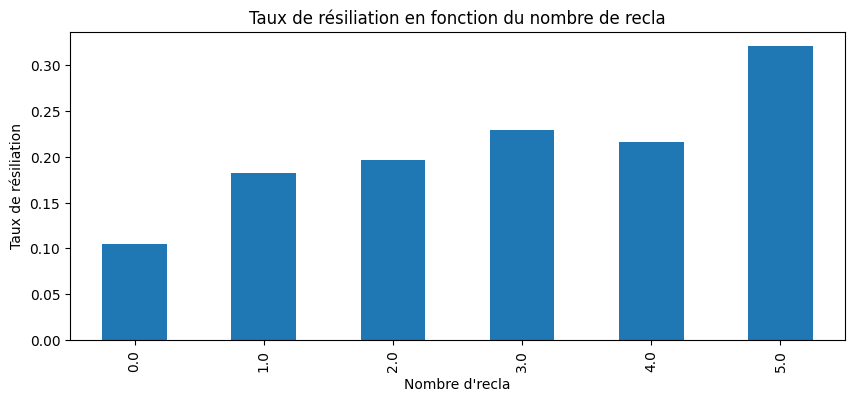

In [32]:
taux_resiliation_par_interaction = (
    df_final.groupby('recla_nombre_bin')['target_resiliation_6mois']
    .mean()
)

taux_resiliation_par_interaction.plot(kind='bar', figsize=(10,4))

plt.ylabel("Taux de résiliation")
plt.xlabel("Nombre d'recla")
plt.title("Taux de résiliation en fonction du nombre de recla")
plt.show()


In [21]:
taux_resiliation_par_interaction = df_final.groupby('interaction_nb_total').agg(
    nb_clients = ('target_resiliation_6mois', 'count'),
    taux_resiliation = ('target_resiliation_6mois', 'mean')
)

taux_resiliation_par_interaction.head(40)

,nb_clients,taux_resiliation
interaction_nb_total,,
0.0,66681,0.072584
1.0,21662,0.113240
2.0,13066,0.135543
3.0,8379,0.137606
4.0,5758,0.154220
5.0,4044,0.163452
6.0,2866,0.183880
7.0,2099,0.205812
8.0,1588,0.183249


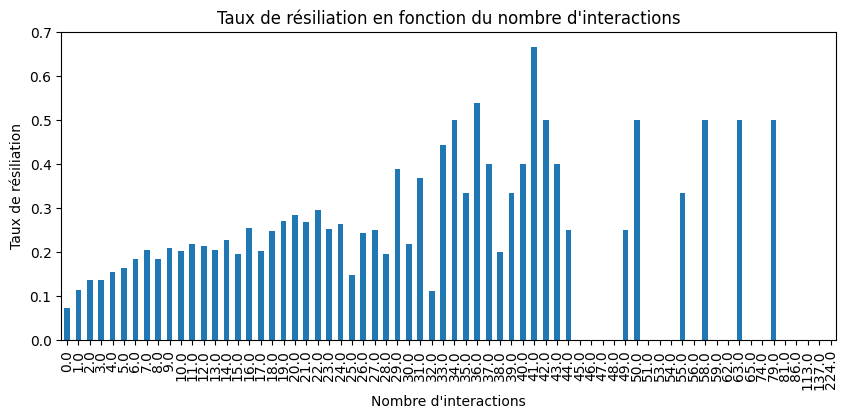

In [22]:
taux_resiliation_par_interaction = (
    df_final.groupby('interaction_nb_total')['target_resiliation_6mois']
    .mean()
)

taux_resiliation_par_interaction.plot(kind='bar', figsize=(10,4))

plt.ylabel("Taux de résiliation")
plt.xlabel("Nombre d'interactions")
plt.title("Taux de résiliation en fonction du nombre d'interactions")
plt.show()


In [27]:
df_final['interaction_nb_total_bin'] = df_final['interaction_nb_total'].clip(upper=21)


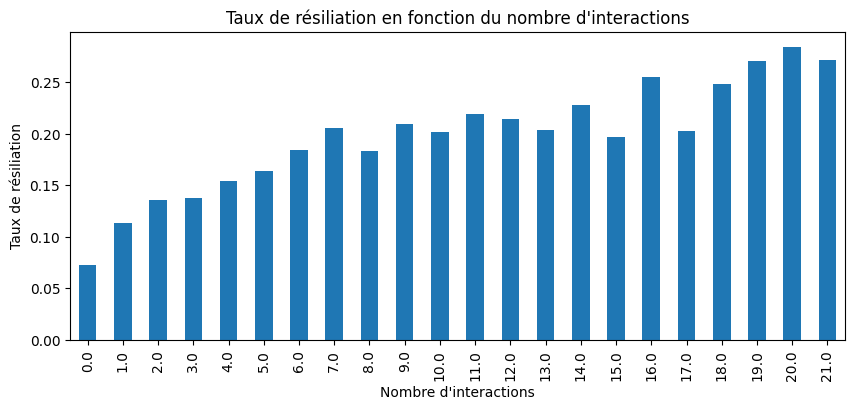

In [29]:
taux_resiliation_par_interaction = (
    df_final.groupby('interaction_nb_total_bin')['target_resiliation_6mois']
    .mean()
)

taux_resiliation_par_interaction.plot(kind='bar', figsize=(10,4))

plt.ylabel("Taux de résiliation")
plt.xlabel("Nombre d'interactions")
plt.title("Taux de résiliation en fonction du nombre d'interactions")
plt.show()
